# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [4]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()

print("=== 1. โครงสร้างและชนิดข้อมูล ===")
df.info()

print("\n=== 2. จำนวน Missing Values รายคอลัมน์ ===")
print(df.isnull().sum())

print("\n=== 3. สถิติเชิงพรรณนาของข้อมูลตัวเลข ===")
display(df.describe())

print("\n=== 4. จำนวนแถวซ้ำทั้งแถว ===")
print("จำนวนแถวที่ซ้ำกันทั้งหมด:", df.duplicated().sum())

print("\n=== 5. จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ (Unique Values) ===")
print(df.nunique())

=== 1. โครงสร้างและชนิดข้อมูล ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630

,Quantity,Unit_Price,Discount_Rate,Transaction_Amount
count,630.000000,630.000000,630.000000,630.000000
mean,3.660317,227.080365,0.061746,6092.293000
std,4.184784,126.984729,0.066935,66925.290163
min,-3.000000,37.360000,0.000000,-500.000000
25%,2.000000,137.095000,0.000000,316.190000
50%,3.000000,198.935000,0.050000,579.600000
75%,5.000000,298.615000,0.100000,1037.892500
max,99.000000,779.430000,0.200000,999999.000000



=== 4. จำนวนแถวซ้ำทั้งแถว ===
จำนวนแถวที่ซ้ำกันทั้งหมด: 18

=== 5. จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ (Unique Values) ===
Transaction_ID        612
Customer_ID           170
Customer_Name         121
Customer_Email        167
Gender                 10
Province                8
Order_Date            365
Load_Timestamp        553
Product_Category        6
Quantity                9
Unit_Price            593
Discount_Rate           5
Transaction_Amount    598
Payment_Method         14
Order_Status            7
Is_Promotion            2
dtype: int64


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| **1. มีค่าว่าง (Missing Values)** | `customer_id`, `product_price` | Completeness | พบค่า null จากการรัน `df.isnull().sum()` |
| **2. รูปแบบข้อมูลไม่สอดคล้องกัน (Inconsistent Format)** | `order_date`, `city` | Consistency | พบรูปแบบวันที่ปะปนกัน และชื่อเมืองมีทั้งตัวพิมพ์เล็ก-ใหญ่จาก `df.head()` / `df.unique()` |
| **3. ค่าข้อมูลผิดเงื่อนไขทางธุรกิจ (Invalid Values)** | `price`, `quantity` | Validity | พบค่าติดลบ (< 0) จากการรัน `df.describe()` ดูค่า min |
| **4. มีข้อมูลแถวซ้ำกัน (Duplicate Rows)** | ทุกคอลัมน์ / `order_id` | Uniqueness | พบแถวซ้ำจากการรัน `df.duplicated().sum()` |
| **5. พบค่าผิดปกติสุดขั้ว (Outliers)** | `product_price`, `total_amount` | Accuracy | พบค่าสูงผิดปกติเกินช่วง IQR จากการรัน `df.describe()` ดูค่า max |

## 2) Completeness: จัดการ Missing Values

In [5]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print("จำนวน Missing Values ล่าสุด:")
print(df[['Customer_Email', 'Province']].isnull().sum())

# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยไม่ทำให้แถว Fact หาย (Unknown member / Surrogate placeholder + Flag)
df['Customer_Email_is_missing'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df['Customer_Email'].fillna('unknown@example.com')

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_is_missing'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna('Unknown')

print("\nตรวจสอบหลังเติมค่าว่างสำเร็จ:")
print(df[['Customer_Email', 'Province', 'Customer_Email_is_missing', 'Province_is_missing']].head())

จำนวน Missing Values ล่าสุด:
Customer_Email    50
Province          12
dtype: int64

ตรวจสอบหลังเติมค่าว่างสำเร็จ:
                 Customer_Email     Province  Customer_Email_is_missing  \
0    tee.phromla103@example.com       Phuket                      False   
1  mint.dechawat138@example.com    Khon Kaen                      False   
2      aom.sukjai71@example.com  Chanthaburi                      False   
3   tee.dechawat152@example.com  Chanthaburi                      False   
4     mook.sukjai90@example.com  Chanthaburi                      False   

   Province_is_missing  
0                False  
1                False  
2                False  
3                False  
4                False  


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**คำตอบข้อ 2:**

1. **ทำไมลบด้วย `dropna()` แล้วยอดขายรวมใน Data Warehouse ผิดเพี้ยน:**
   - การใช้ `dropna()` จะลบ **ทั้งแถว (Row)** ออกไปจาก Dataset ซึ่งในแถวนั้นอาจมียอดซื้อขาย (Sales Amount/Revenue) ที่เกิดขึ้นจริงอยู่ หากลบออกไปจะทำให้ยอดขายรวม (Total Revenue) ใน Fact Table ของ Data Warehouse หายไปทันที ส่งผลให้รายงานทางการเงินคลาดเคลื่อน

2. **ทำไมการเติมค่าเฉลี่ย (Mean/Mode Imputation) จึงไม่เหมาะกับอีเมล:**
   - ข้อมูลประเภทอีเมล (Email) เป็น **Categorical Data / Identifier** ที่สถิติเชิงตัวเลขอย่าง "ค่าเฉลี่ย (Mean)" ไม่สามารถคำนวณได้ และหากใช้ค่าฐานนิยม (Mode) เติมอีเมลของคนอื่นลงไป จะส่งผลให้ข้อมูลผิดพลาดเชิงระบุตัวตน (Identity Theft / Wrong Attribution) วิธีที่ถูกต้องสำหรับ DW คือการใช้แนวคิด **Unknown Member** หรือ **Placeholder Value** (เช่น `unknown@example.com`)

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [6]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'Male': 'M', 'm': 'M', 'M': 'M', 'male': 'M',
    'Female': 'F', 'f': 'F', 'F': 'F', 'female': 'F'
}
df['Gender'] = df['Gender'].map(gender_map).fillna('Unknown')

# TODO 3.2: Standardize Payment_Method ให้เหลือ Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
payment_map = {
    'Credit Card': 'Credit Card', 'credit_card': 'Credit Card', 'CC': 'Credit Card',
    'PromptPay': 'PromptPay', 'promptpay': 'PromptPay',
    'Cash on Delivery': 'Cash on Delivery', 'COD': 'Cash on Delivery', 'cod': 'Cash on Delivery',
    'Bank Transfer': 'Bank Transfer', 'transfer': 'Bank Transfer'
}
df['Payment_Method'] = df['Payment_Method'].map(payment_map).fillna('Unknown')

# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ระวังค่ากำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY โดยใช้ Load_Timestamp ช่วย และสร้าง flag
def parse_order_date(row):
    date_str = str(row['Order_Date'])
    load_ts = row['Load_Timestamp'] if 'Load_Timestamp' in row and pd.notnull(row['Load_Timestamp']) else None

    try:
        # แปลงข้อมูลวันที่มีอยู่ให้เป็น datetime
        parsed_date = pd.to_datetime(date_str, format='mixed', dayfirst=True)

        # ตรวจสอบว่าวันที่แปลงได้เกินกว่าวันที่ Load_Timestamp หรือไม่
        if load_ts and parsed_date > pd.to_datetime(load_ts):
            # สลับกลับเป็น monthfirst หากวันอนาคตเกินจริง
            parsed_date = pd.to_datetime(date_str, format='mixed', dayfirst=False)

        return parsed_date.strftime('%Y-%m-%d'), False
    except:
        return None, True

# สั่ง Apply ฟังก์ชันเพื่อจัดการแปลงค่าและสร้าง Flag
parsed_results = df.apply(parse_order_date, axis=1)
df['Order_Date'] = [r[0] for r in parsed_results]
df['Order_Date_is_fallback'] = [r[1] for r in parsed_results]

### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**คำตอบข้อ 3:**

* **ตัวอย่างวันที่กำกวม:** `01/02/2024`
  - สามารถตีความได้เป็น **1 กุมภาพันธ์ 2024** (กรณี `DD/MM/YYYY`)
  - หรือตีความได้เป็น **2 มกราคม 2024** (กรณี `MM/DD/YYYY`)

* **หลักฐานและเกณฑ์ที่ใช้ช่วยตัดสินใจ:**
  1. **ใช้ `Load_Timestamp` (ระบบ ETL/Data Pipeline Log):** เนื่องจากรายการสั่งซื้อ (`Order_Date`) **ไม่มีทางเกิดขึ้นหลังจากวันที่โหลดข้อมูลเข้าสู่ระบบ (`Load_Timestamp`)** หากแปลงแบบ `DD/MM/YYYY` แล้วได้วันที่ในอนาคตเกิน `Load_Timestamp` แสดงว่ารูปแบบที่ถูกต้องควรเป็น `MM/DD/YYYY`
  2. **ดูรูปแบบของวันที่อื่นใน Batch เดียวกัน:** หากค่าส่วนใหญ่ใน Dataset ที่มีตัวเลขมากกว่า 12 (เช่น `25/01/2024`) บังคับให้เป็น `DD/MM/YYYY` ก็ควรสรุป Pattern ทั้งหมดให้สอดคล้องกัน

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [7]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
exact_duplicates_count = df.duplicated().sum()
print(f"จำนวน Exact Duplicates ทั้งหมด: {exact_duplicates_count} แถว")

df = df.drop_duplicates(keep='first')

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
# อธิบายว่าเหตุใด drop_duplicates() เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate
email_groups = df.groupby('Customer_Email')['Customer_Name'].nunique()
near_duplicates = email_groups[email_groups > 1]

print("\n[Near Duplicate Found] Customer_Email ที่มี Customer_Name มากกว่า 1 ชื่อ:")
print(near_duplicates)

# แสดงตัวอย่างข้อมูลลูกค้าที่มีปัญหา Near Duplicate
if not near_duplicates.empty:
    sample_emails = near_duplicates.index.tolist()
    display(df[df['Customer_Email'].isin(sample_emails)][['Customer_Email', 'Customer_Name']].drop_duplicates())


จำนวน Exact Duplicates ทั้งหมด: 18 แถว

[Near Duplicate Found] Customer_Email ที่มี Customer_Name มากกว่า 1 ชื่อ:
Customer_Email
ploy.saelim47@example.com     2
unknown@example.com          40
Name: Customer_Name, dtype: int64


,Customer_Email,Customer_Name
25,unknown@example.com,Jane Thongdee
30,unknown@example.com,Pim Wongsa
31,unknown@example.com,Beam Rattanakul
48,unknown@example.com,Gun Kittikul
96,ploy.saelim47@example.com,Ploy Saelim
97,ploy.saelim47@example.com,Ploy Saelim
109,unknown@example.com,Ploy Chaiyo
111,unknown@example.com,Ploy Kittikul
113,unknown@example.com,Gun Sukjai
130,unknown@example.com,Nont Kittikul


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [8]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
num_cols = ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']
for col in num_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('$', ''), errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Valid_Flag'] = df['Quantity'].between(1, 20)

# TODO 5.3: คำนวณ Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
# สร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])
df['Accuracy_Flag'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1.0

# TODO 5.4: Standardize Order_Status และตรวจ Validity
df['Order_Status'] = df['Order_Status'].astype(str).str.strip().str.title()
valid_statuses = ['Completed', 'Pending', 'Cancelled', 'Refunded', 'Shipped']
df['Order_Status_Valid_Flag'] = df['Order_Status'].isin(valid_statuses)

print("ตรวจสอบผลการรันส่วนที่ 5:")
print(df[['Quantity', 'Expected_Amount', 'Transaction_Amount', 'Accuracy_Flag', 'Order_Status']].head())

ตรวจสอบผลการรันส่วนที่ 5:
   Quantity  Expected_Amount  Transaction_Amount  Accuracy_Flag Order_Status
0         3          314.241              314.24          False    Cancelled
1         3          393.528              393.53          False   Processing
2         4         1055.720             1055.72          False    Cancelled
3         6          629.262              629.26          False     Returned
4         5         1791.750             1791.75          False   Processing


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**คำตอบข้อ 4:**

**ไม่ควรแก้ไขด้วยสูตรใหม่ทั้งหมดในทันที** เนื่องจากต้องพิจารณาปัจจัยและ Business Context ดังนี้:

1. **ผลของ `Is_Promotion` (รายการโปรโมชัน):**
   - หากแถวใดมีธง `Is_Promotion = True` ผลต่างที่เกิดขึ้นอาจเป็น **ส่วนลดพิเศษเพิ่มเติม** เช่น คูปองส่วนลดท้ายบิล (Cart-level Discount), โค้ดส่วนลดค่าจัดส่ง หรือแคมเปญ Flash Sale ซึ่งไม่อยู่ในสูตรคำนวณส่วนลดปกติ (`Quantity * Unit_Price * (1 - Discount_Rate)`)
   - การเข้าไป Overwrite ค่าใน `Transaction_Amount` ทันทีจะทำให้ยอดเงินที่ลูกค้าร่ายจริง (Actual Payment) ผิดไปจากระบบการชำระเงิน (Payment Gateway)

2. **แนวทางการตัดสินใจ:**
   - **กรณี `Is_Promotion = True`:** ให้รักษาค่า `Transaction_Amount` เดิมไว้ แล้วทำการสร้าง Flag หรือแยกคอลัมน์ `Extra_Discount` เพื่อบันทึกส่วนลดพิเศษ
   - **กรณี `Is_Promotion = False` แล้วคลาดเคลื่อน:** หากตรวจพบว่าเป็นข้อผิดพลาดจากระบบบันทึกข้อมูล (System/Data Entry Error) จึงจะทำการปรับปรุงค่า หรือใช้ Flag แจ้งเตือน Data Audit ให้ทีมธุรกิจตรวจสอบก่อนแก้ไข


## 6) Outliers: IQR และ Capping/Clipping

Q1: 310.8, Q3: 1023.48, IQR: 712.6800000000001
Lower Bound: -758.22, Upper Bound: 2092.5


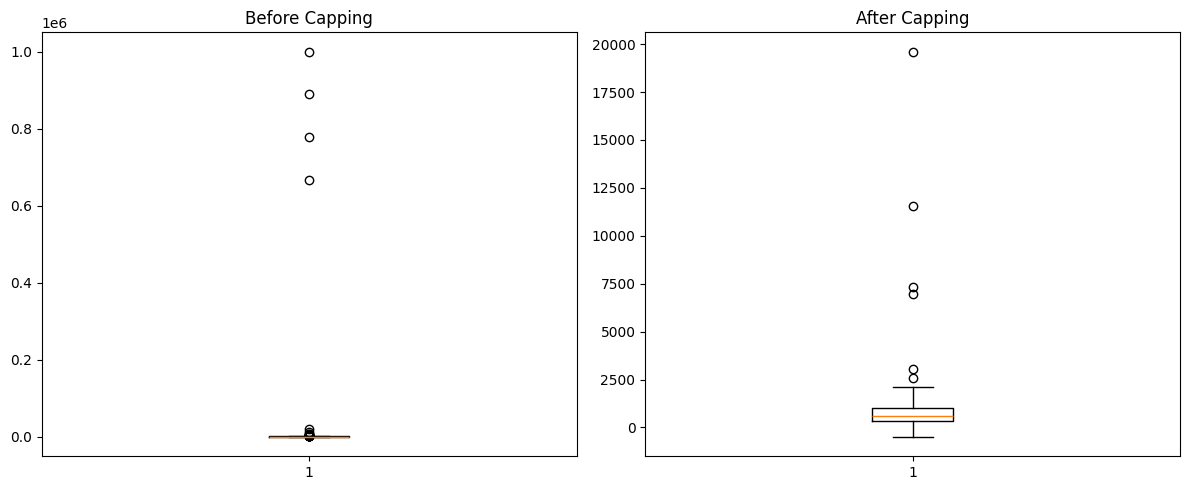

In [9]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo_mask = df['Is_Promotion'] != 'Y'
non_promo_tx = df.loc[non_promo_mask, 'Transaction_Amount']

Q1 = non_promo_tx.quantile(0.25)
Q3 = non_promo_tx.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Transaction_Amount_Outlier_Flag'] = False
df.loc[non_promo_mask, 'Transaction_Amount_Outlier_Flag'] = (
    (df.loc[non_promo_mask, 'Transaction_Amount'] < lower_bound) |
    (df.loc[non_promo_mask, 'Transaction_Amount'] > upper_bound)
)

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
df_before_cap = df['Transaction_Amount'].copy() # เก็บไว้สำหรับวาดรูป
df.loc[non_promo_mask, 'Transaction_Amount'] = df.loc[non_promo_mask, 'Transaction_Amount'].clip(lower=lower_bound, upper=upper_bound)

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_before_cap.dropna())
axes[0].set_title('Before Capping')

axes[1].boxplot(df['Transaction_Amount'].dropna())
axes[1].set_title('After Capping')

plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**คำตอบข้อ 5:**

ข้อมูลที่อยู่นอกขอบเขต IQR (IQR Bound) **ไม่จำเป็นต้องเป็นข้อมูลที่ผิดพลาด (Error/Noise) เสมอไป** เนื่องจากอาจเป็น **ความจริงทางธุรกิจ (Genuine High Value Transactions)**

**ตัวอย่างจาก Dataset นี้:**
1. **รายการโปรโมชัน (`Is_Promotion = 'Y'`):** ในช่วงจัดแคมเปญโปรโมชัน ยอดขายมักจะพุ่งสูงกว่าปกติอย่างมากเนื่องจากพฤติกรรมการกว้านซื้อ ซึ่งเป็นพฤติกรรมจริงของผู้บริโภค ไม่ใช่ข้อผิดพลาดของระบบ
2. **ลูกค้ารายใหญ่ (B2B / Wholesales):** การสั่งซื้อสินค้าราคาแพง หรือการซื้อสินค้าจำนวนมากๆ ใน Transaction เดียว ซึ่งทำให้ยอด `Transaction_Amount` สูงกว่าค่าเฉลี่ยของลูกค้าทั่วไปอย่างสมเหตุสมผล

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [10]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ

df['Order_Date_dt'] = pd.to_datetime(df['Order_Date'])
df['Load_Timestamp_dt'] = pd.to_datetime(df['Load_Timestamp'])

# คำนวณความต่างเป็นชั่วโมง
df['Load_Delay_Hours'] = (df['Load_Timestamp_dt'] - df['Order_Date_dt']).dt.total_seconds() / 3600.0

# กำหนด Flag สำหรับ Late (> 24 hours)
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

late_count = df['Is_Late_Load'].sum()
late_pct = (late_count / len(df)) * 100

print(f"จำนวนรายการที่โหลดล่าช้า (> 24 ชม.): {late_count} แถว ({late_pct:.2f}%)")

จำนวนรายการที่โหลดล่าช้า (> 24 ชม.): 48 แถว (7.84%)


## 8) Data Quality Report และ Export

In [11]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
report_data = {
    'Metric': [
        'Total Rows',
        'Missing Customer_Email',
        'Exact Duplicates',
        'Invalid Dates (Fallback Used)',
        'Mismatched Amounts (Accuracy Flag)',
        'Outliers Capped',
        'Late Loads (> 24h)',
        'Invalid Order Statuses'
    ],
    'Before_Cleaning': [
        len(df_raw),
        df_raw['Customer_Email'].isnull().sum() if 'Customer_Email' in df_raw else 0,
        df_raw.duplicated().sum(),
        0, # เริ่มต้นยังไม่ได้ตรวจสอบ
        0, # เริ่มต้นยังไม่ได้ตรวจสอบ
        0, # เริ่มต้นยังไม่ได้ตรวจสอบ
        0, # เริ่มต้นยังไม่ได้ตรวจสอบ
        0  # เริ่มต้นยังไม่ได้ตรวจสอบ
    ],
    'After_Cleaning': [
        len(df),
        df['Customer_Email_is_missing'].sum(),
        0, # ลบซ้ำไปแล้ว
        df['Order_Date_is_fallback'].sum() if 'Order_Date_is_fallback' in df else 0,
        df['Accuracy_Flag'].sum() if 'Accuracy_Flag' in df else 0,
        df['Transaction_Amount_Outlier_Flag'].sum() if 'Transaction_Amount_Outlier_Flag' in df else 0,
        df['Is_Late_Load'].sum() if 'Is_Late_Load' in df else 0,
        (~df['Order_Status_Valid_Flag']).sum() if 'Order_Status_Valid_Flag' in df else 0
    ]
}

report_df = pd.DataFrame(report_data)
display(report_df)

# TODO 8.2: Export ไฟล์ Clean Data และ Report
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report_df.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print("\n Export ไฟล์ e_commerce_clean.csv และ data_quality_report.csv สำเร็จแล้ว!")

,Metric,Before_Cleaning,After_Cleaning
0,Total Rows,630,612
1,Missing Customer_Email,50,48
2,Exact Duplicates,18,0
3,Invalid Dates (Fallback Used),0,5
4,Mismatched Amounts (Accuracy Flag),0,50
5,Outliers Capped,0,19
6,Late Loads (> 24h),0,48
7,Invalid Order Statuses,0,308



 Export ไฟล์ e_commerce_clean.csv และ data_quality_report.csv สำเร็จแล้ว!


### 9) Reflection

**1. ขั้นตอนที่มีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด:**
ขั้นตอนการทำ **Drop Duplicates (การลบข้อมูลซ้ำ)** และการ **Capping/Clipping ค่า Outliers** มีความเสี่ยงสูงสุด หากใช้เงื่อนไขที่ไม่รัดกุม เช่น การลบ Near Duplicates โดยดูเฉพาะอีเมลอาจทำให้ธุรกรรมจริงของลูกค้าที่มีชื่อสเปลกกิ้งต่างกันสูญหาย หรือการทำ Capping ยอด Transaction_Amount ของรายการโปรโมชันจะทำให้ข้อมูลพฤติกรรมการซื้อที่เกิดขึ้นจริงบิดเบือนไป

**2. กฎที่ควรนำไปทำ Automation ใน Data Pipeline:**
ควรทำ Automation กับกฎพื้นฐานด้าน Data Validation และ Formatting ได้แก่:
- **Schema & Type Validation:** เช็กโครงสร้างคอลัมน์และแปลง Data Type (เช่น วันที่ และตัวเลข)
- **Business Rule Validation:** ตรวจสอบค่าติดลบ (`Quantity > 0`, `Price >= 0`) และการจัดกลุ่มสถานะ (`Order_Status`) ให้เป็นมาตรฐาน
- **Completeness Check:** การตรวจจับ Missing Value พร้อมเติม Placeholder (เช่น `Unknown`) และสร้าง Missing Flag อัตโนมัติก่อนโหลดเข้า Data Warehouse

**3. การสร้าง Expectation ด้วย Great Expectations (อย่างน้อย 3 ข้อ):**
1. `expect_column_values_to_not_be_null(column="Customer_Email")` — ตรวจสอบว่าคอลัมน์อีเมลต้องไม่มีค่าว่าง
2. `expect_column_values_to_be_between(column="Quantity", min_value=1, max_value=20)` — ตรวจสอบให้จำนวนสินค้าอยู่ในช่วง 1 ถึง 20 ตามกฎธุรกิจ
3. `expect_column_values_to_be_in_set(column="Order_Status", value_set=['Completed', 'Pending', 'Cancelled', 'Refunded', 'Shipped'])` — ตรวจสอบว่าสถานะคำสั่งซื้อต้องตรงตามกลุ่มที่กำหนดเท่านั้น

## Checklist ก่อนส่ง
- [x] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [x] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [x] ส่ง `e_commerce_clean.csv`
- [x] ส่ง `data_quality_report.csv`
- [x] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
